In [173]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,roc_auc_score
from sklearn.ensemble import RandomForestClassifier


In [174]:
df=pd.read_csv("diabetes.csv")

In [175]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [176]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [177]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [178]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


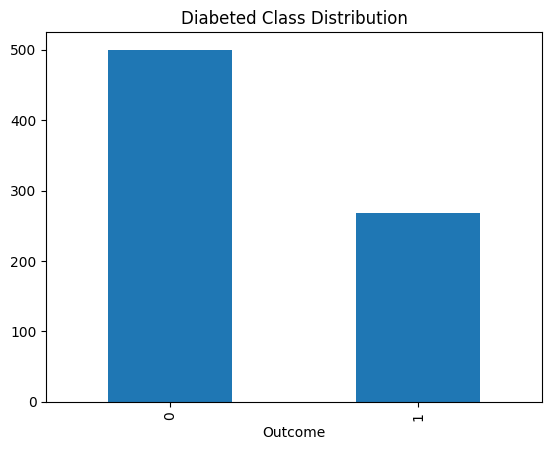

In [179]:
df['Outcome'].value_counts().plot(kind='bar')
plt.title("Diabeted Class Distribution")
plt.show()

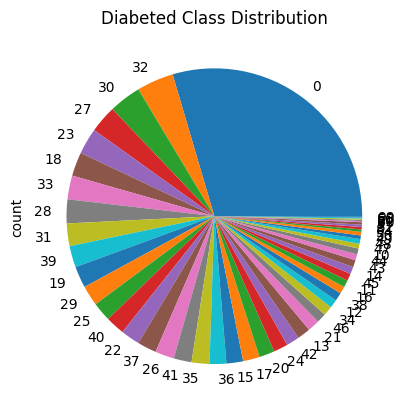

In [180]:
df['SkinThickness'].value_counts().plot(kind='pie')
plt.title("Diabeted Class Distribution")
plt.show()

In [181]:
len(df[(df['BloodPressure'] < 100) & (df['BloodPressure'] > 50)])

688

In [182]:
print(df.duplicated().sum())

0


In [183]:
y=df['Outcome']
x=df.drop('Outcome',axis=1)

In [184]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=60)

In [185]:
model=RandomForestClassifier()
model.fit(xtrain,ytrain)

RandomForestClassifier()

In [186]:
output=model.predict(xtest)
accuracy=accuracy_score(ytest,output)
print(accuracy)

0.7987012987012987


In [187]:
pregnancies=input('enter the number of pregnancies')
glucose=input('enter the glucose level')
bloodpressure=input('enter the blood pressure')
skinthickness=input('enter the skin thickness')
insulin=input('enter the insulin level')
bmi=input('enter the bmi')
diabetespedigreefunction=input('enter the diabetes pedigree function')
age=input('enter the age')
input_data=(pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction,age)
ypredict=model.predict([input_data])
if ypredict[0]==0:
  print('The person is not diabetic')
else:
  print('The person is diabetic')

enter the number of pregnancies6
enter the glucose level140
enter the blood pressure72
enter the skin thickness40
enter the insulin level23
enter the bmi31
enter the diabetes pedigree function0.8
enter the age19
The person is diabetic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
